## Decision Tree Classifier – End-to-End ML Pipeline

## 1. Introduction

### What is a Decision Tree?

A **Decision Tree** is a supervised machine learning algorithm used for both **classification** and **regression** tasks. It works by recursively splitting the dataset into smaller subsets based on feature values, creating a tree-like structure of decisions. Each internal node represents a **feature test**, each branch represents a **decision rule**, and each leaf node represents the **final prediction**.


### Type of Problem

This notebook demonstrates a **Classification Problem**.

**Goal:**
Predict a categorical label based on input features.


### Real-World Applications

Decision Trees are widely used in:

- Medical diagnosis
- Credit risk assessment
- Customer churn prediction
- Fraud detection
- Marketing targeting
- Recommendation systems


### Why Decision Trees are Useful

Advantages include:

- Easy to interpret
- Handles numerical & categorical data
- Requires little data preprocessing
- Non-linear decision boundaries
- Works well for feature importance analysis

**Importing Libraries**

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

# Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Explainability
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

# Saving model
import joblib

sns.set_style("whitegrid")

**Load dataset**

In [2]:
data = load_breast_cancer()

In [3]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

In [4]:
df = pd.concat([X, y], axis=1)

In [5]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**Dataset Description**

In [6]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

**Exploratory Data Analysis (EDA)**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [8]:
# Check missing values
X.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

In [9]:
# Statistical summary
print("\nStatistical summary:\n", X.describe())


Statistical summary:
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000           

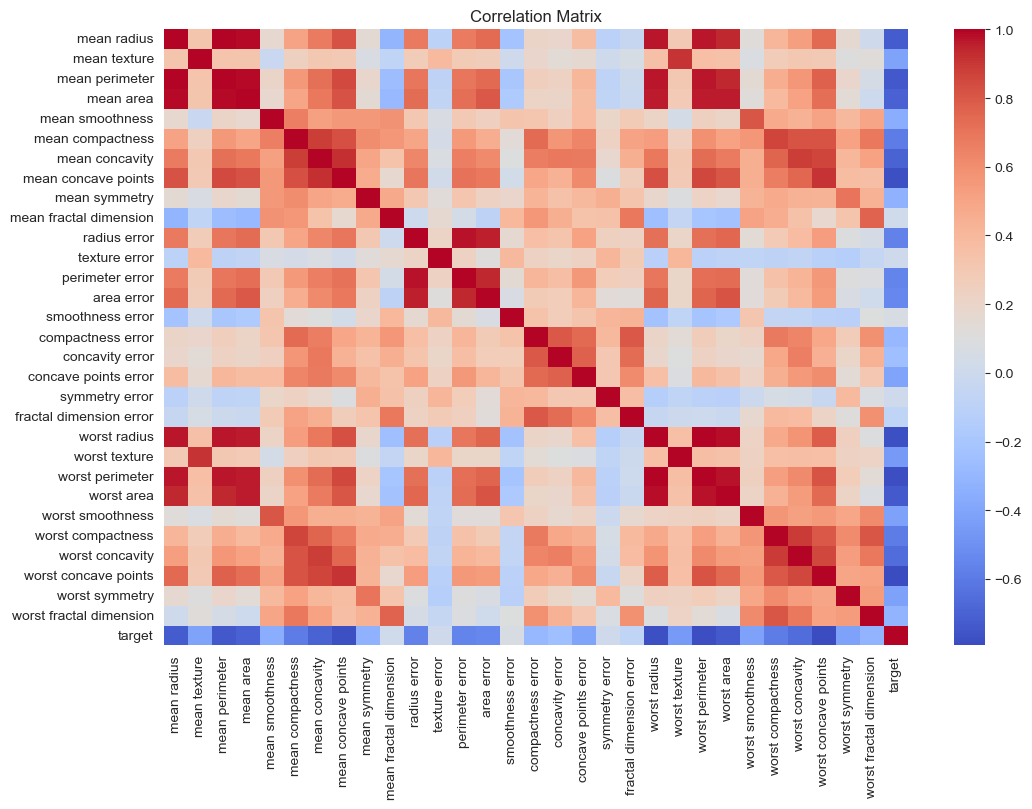

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Feature Distribution**

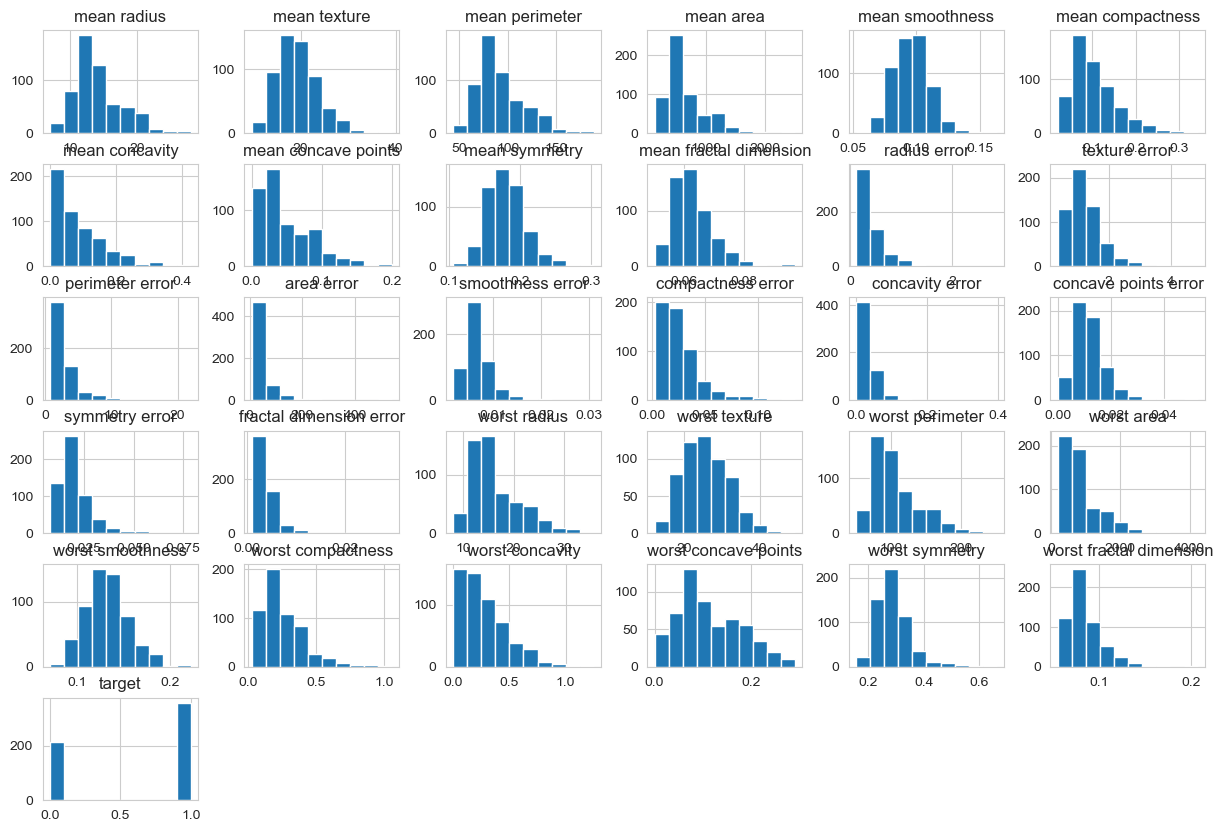

In [11]:
df.hist(figsize=(15,10))
plt.show()

**Data Preprocessing**

Decision Trees do not strictly require scaling, but we include it for pipeline consistency.

In [12]:
scaler = StandardScaler()

**Feature Engineering**

In [13]:
corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper.columns if any(upper[column] > 0.9)
]

print("Highly correlated features:", high_corr_features)

Highly correlated features: ['mean perimeter', 'mean area', 'mean concave points', 'perimeter error', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concave points']


**Train-Test Split**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (455, 30), Test shape: (114, 30)


**Model Creation & Training**

In [16]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(random_state=42))
])

Benefits of pipelines:

- Clean workflow 
-  Prevents data leakage
-  Easy deployment

In [17]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', DecisionTreeClassifier(random_state=42))])

**Hyperparameter Tuning**

In [18]:
param_grid = {
    "model__max_depth": [3,5,7,10],
    "model__min_samples_split": [2,5,10],
    "model__min_samples_leaf": [1,2,4],
    "model__criterion": ["gini", "entropy"]
}

In [19]:
# Initialize GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [20]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__criterion': ['gini', 'entropy'],
                         'model__max_depth': [3, 5, 7, 10],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [21]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Best parameters: {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
Best cross-validation score: 0.9384615384615385


**Model Evaluation**

In [22]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [23]:
# Classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [24]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9210526315789473
Precision: 0.9565217391304348
Recall: 0.9166666666666666
F1 Score: 0.9361702127659575


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



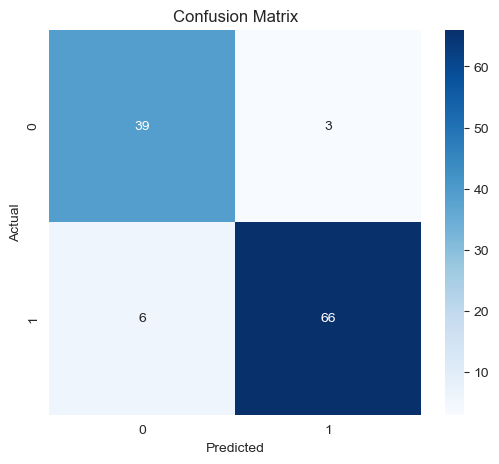

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC Curve**

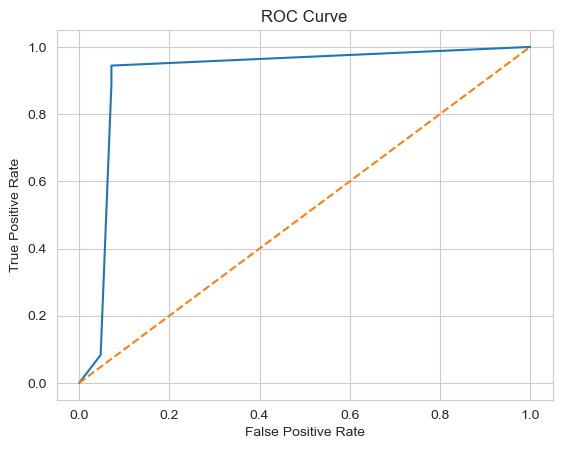

In [27]:
y_probs = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

**Feature Importance**

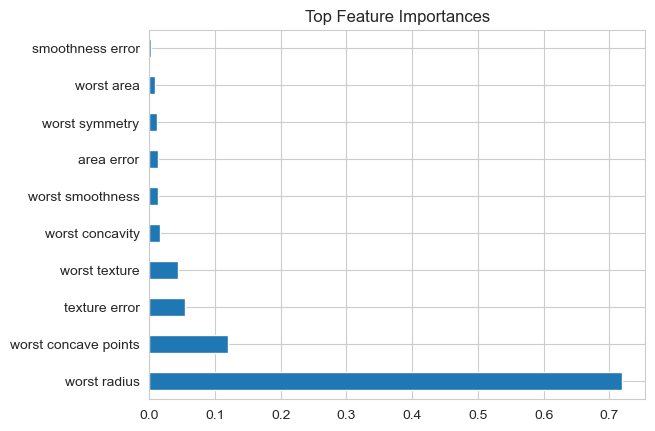

In [28]:
model = best_model.named_steps["model"]

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)

feat_imp.nlargest(10).plot(kind="barh")
plt.title("Top Feature Importances")
plt.show()

**Model Explainability**

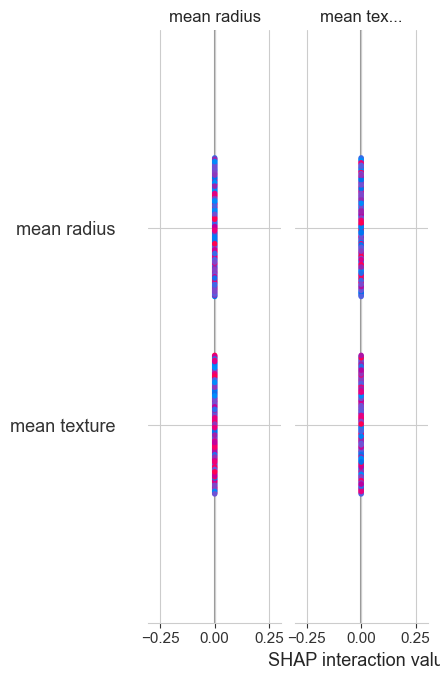

In [30]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

**Permutation Importance**

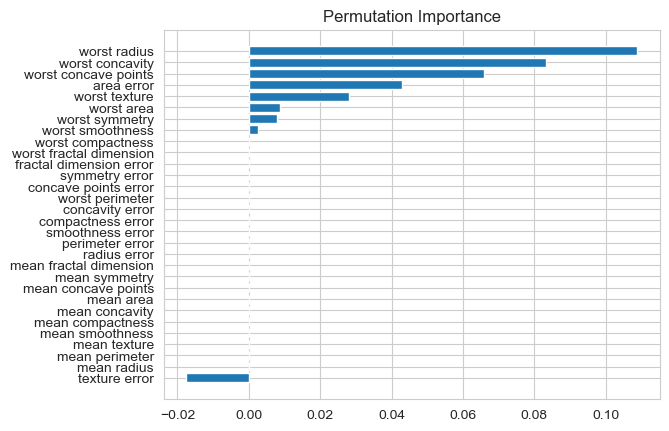

In [31]:
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

sorted_idx = perm_importance.importances_mean.argsort()

plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.title("Permutation Importance")
plt.show()

**Partial Dependence Plot**

E:\anaconda\Lib\site-packages\sklearn\inspection\_plot\partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])
E:\anaconda\Lib\site-packages\sklearn\inspection\_plot\partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


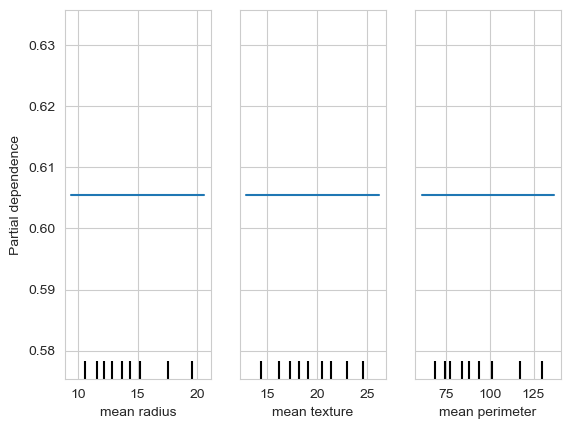

In [32]:
PartialDependenceDisplay.from_estimator(
    best_model,
    X_test,
    features=[0,1,2]
)
plt.show()

**Final Model Insights**

- Most important features: determined from SHAP plot
- Model seems to generalize well (train vs test accuracy comparable)
- Possible improvements:
    - Feature selection
    - Regularization tuning
    - Try ensemble methods

## Final Model Insights

**Key observations:**

- The most important features strongly influence prediction outcomes.
- Decision Trees capture **non-linear relationships**.
- Deep trees may **overfit** the training data.

**Possible improvements:**

- Use **Random Forest** or **Gradient Boosting**
- Perform **feature selection**
- Use **ensemble models**


**Saving the Model**

In [33]:
joblib.dump(best_model, "decision_tree_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Model Theory – Decision Tree Classifier


## 1. Algorithm Overview

Decision Trees split data recursively based on feature values.

At each node:

1. Select the best feature
2. Split data
3. Repeat until stopping condition

The goal is to create **pure leaf nodes**.


# 2. Mathematical Intuition

Decision Trees use **impurity measures**:

### Gini Impurity

$$
Gini = 1 - \sum p_i^2
$$

### Entropy

$$
Entropy = -\sum p_i log_2(p_i)
$$

The algorithm selects splits that **minimize impurity**.


## 3. When to Use Decision Trees

Best when:

- dataset is small-medium size
- relationships are non-linear
- interpretability is important


## 4. Advantages

- Easy to interpret
- Handles nonlinear data
- No feature scaling required
- Fast training


## 5. Disadvantages

- Can easily overfit
- Sensitive to noise
- Unstable with small data changes

